# King PSF Fitting Demo

This notebook demonstrates how to use the `KingPSFFitter` to fit King function parameters to Monte Carlo signal events.

The fitter allows you to parameterize the angular error distribution (PSF) as a function of arbitrary observables like energy, declination, and angular uncertainty.

In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt

# Import the fitting module
from kingmaker.fitting import KingPSFFitter
from kingmaker.pdf import KingPDF

## 1. Load Signal Monte Carlo

We'll load signal MC events from a numpy file. The events should be structured arrays containing:
- `ra`, `dec`: Reconstructed coordinates (radians)
- `true_ra`, `true_dec`: True coordinates (radians)  
- Additional observables for parameterization (e.g., energy, angular uncertainty)
- Optional: event weights

In [2]:
# Get the data directory from environment variable
os.environ["DATASET_FILES"] = "/Users/mjlarson/icecube/data/ana/analyses/"
#dataset_dir = os.path.expandvars(os.environ.get('DATASET_FILES', '/data/ana/analyses/'))
dataset_dir = "/Users/mjlarson/icecube/data/ana/analyses/"
signal_file = os.path.join(dataset_dir, 'ps_tracks/version-004-p04/IC86_2016_MC.npy')
print(signal_file, os.path.exists(signal_file))

# Load signal MC events
# Expected structure: structured array with fields like:
#   'ra', 'dec', 'trueRa', 'trueDec', 'logE', 'sigma', 'oneweight'
try:
    signal_events = np.load(signal_file)
    print(f"Loaded {len(signal_events)} signal MC events")
    print(f"Available fields: {signal_events.dtype.names}")
except FileNotFoundError:
    print(f"Signal file not found at {signal_file}")
    print("Generating synthetic data for demonstration...")
    
    # Generate synthetic signal MC for demonstration
    n_events = 50000
    
    # Random true positions
    true_ra = np.random.uniform(0, 2*np.pi, n_events)
    true_dec = np.arcsin(np.random.uniform(-1, 1, n_events))
    
    # Energy distribution
    logE = np.random.uniform(2, 6, n_events)  # 100 GeV to 1 PeV
    
    # Angular uncertainty correlates with energy
    sigma = np.radians(10**(0.5 - 0.3*logE))  # Better resolution at high energy
    sigma = np.clip(sigma, np.radians(0.1), np.radians(10))
    
    # Simulate reconstruction errors
    ra_error = np.random.normal(0, sigma)
    dec_error = np.random.normal(0, sigma)
    
    ra = true_ra + ra_error / np.cos(true_dec)
    dec = true_dec + dec_error
    
    # Clip to valid ranges
    ra = np.mod(ra, 2*np.pi)
    dec = np.clip(dec, -np.pi/2, np.pi/2)
    
    # Create structured array
    signal_events = np.zeros(n_events, dtype=[
        ('ra', 'f8'), ('dec', 'f8'),
        ('trueRa', 'f8'), ('trueDec', 'f8'),
        ('logE', 'f8'), ('sigma', 'f8'),
        ('oneweight', 'f8')
    ])
    
    signal_events['ra'] = ra
    signal_events['dec'] = dec
    signal_events['trueRa'] = true_ra
    signal_events['trueDec'] = true_dec
    signal_events['logE'] = logE
    signal_events['sigma'] = sigma
    signal_events['oneweight'] = np.random.uniform(0.5, 2.0, n_events)
    
    print(f"Generated {len(signal_events)} synthetic events")
    print(f"Fields: {signal_events.dtype.names}")

/Users/mjlarson/icecube/data/ana/analyses/ps_tracks/version-004-p04/IC86_2016_MC.npy True
Loaded 12169153 signal MC events
Available fields: ('run', 'event', 'subevent', 'ra', 'dec', 'azi', 'zen', 'time', 'logE', 'angErr', 'trueRa', 'trueDec', 'trueE', 'ow')


## 2. Define Parameterization Binning

Specify which observables to use for parameterization and how to bin them.
You can use:
- Integer: number of equal-probability bins
- Array: explicit bin edges

In [13]:
# Define binning for parameterization
# This will create a multi-dimensional grid of bins
parametrization_bins = {
    'logE': 10, # 10 energy bins from 100 GeV to 1 PeV
    'dec': 10,  # 10 dec bins
    'angErr': 20 # 10 equal-probability bins in angular uncertainty
}

print("Parameterization binning:")
for key, val in parametrization_bins.items():
    if isinstance(val, int):
        print(f"  {key}: {val} equal-probability bins")
    else:
        print(f"  {key}: {len(val)-1} bins with edges {val}")

Parameterization binning:
  logE: 10 equal-probability bins
  dec: 10 equal-probability bins
  angErr: 20 equal-probability bins


## 3. Initialize the KingPSFFitter

Create the fitter object with the desired configuration.

In [14]:
# Initialize the fitter
fitter = KingPSFFitter(
    signal_events=signal_events,
    parametrization_bins=parametrization_bins,
    dpsi_nbins=51,            # Number of bins in angular error for fitting
    minimum_counts=100,       # Minimum events required per bin for fitting
    weight_field='ow',        # Field to use for event weights
    spectral_indices=[2.0, 2.5, 3.0],  # Spectral indices to try
    angular_cutoff=np.pi      # Maximum angular separation
)

print(f"\nFitter initialized:")
print(f"  Parameterization shape: {fitter.parametrization_shape}")
print(f"  Total bins: {np.prod(fitter.parametrization_shape)}")
print(f"  Spectral indices: {fitter.spectral_indices}")


Fitter initialized:
  Parameterization shape: [10, 10, 20]
  Total bins: 2000
  Spectral indices: [2.  2.5 3. ]


## 4. Fit King Parameters

Run the fitting procedure. This will fit King distribution parameters (alpha, beta) in each bin.

In [15]:
# Run the fitting
results = fitter.fit_all_bins(verbose=True)

print("\nFit results summary:")
print(f"  Alpha shape: {results['alpha'].shape}")
print(f"  Beta shape: {results['beta'].shape}")
print(f"  Total events used: {results['event_counts'].sum()}")
print(f"  Bins with successful fits: {(results['event_counts'] >= fitter.minimum_counts).sum()}")

Fitting King PSF in 2000 bins...
  Spectral indices: [2.  2.5 3. ]
  Binning dimensions: ['logE', 'dec', 'angErr']

  Spectral index γ = 2.00
    Fitted 1954 bins, skipped 46 bins

  Spectral index γ = 2.50
    Fitted 1954 bins, skipped 46 bins

  Spectral index γ = 3.00
    Fitted 1954 bins, skipped 46 bins

Fitting complete!

Fit results summary:
  Alpha shape: (3, 10, 10, 20)
  Beta shape: (3, 10, 10, 20)
  Total events used: 36507450
  Bins with successful fits: 6000


## 5. Visualize Fit Results

Plot the fitted parameters as a function of the parameterization variables.

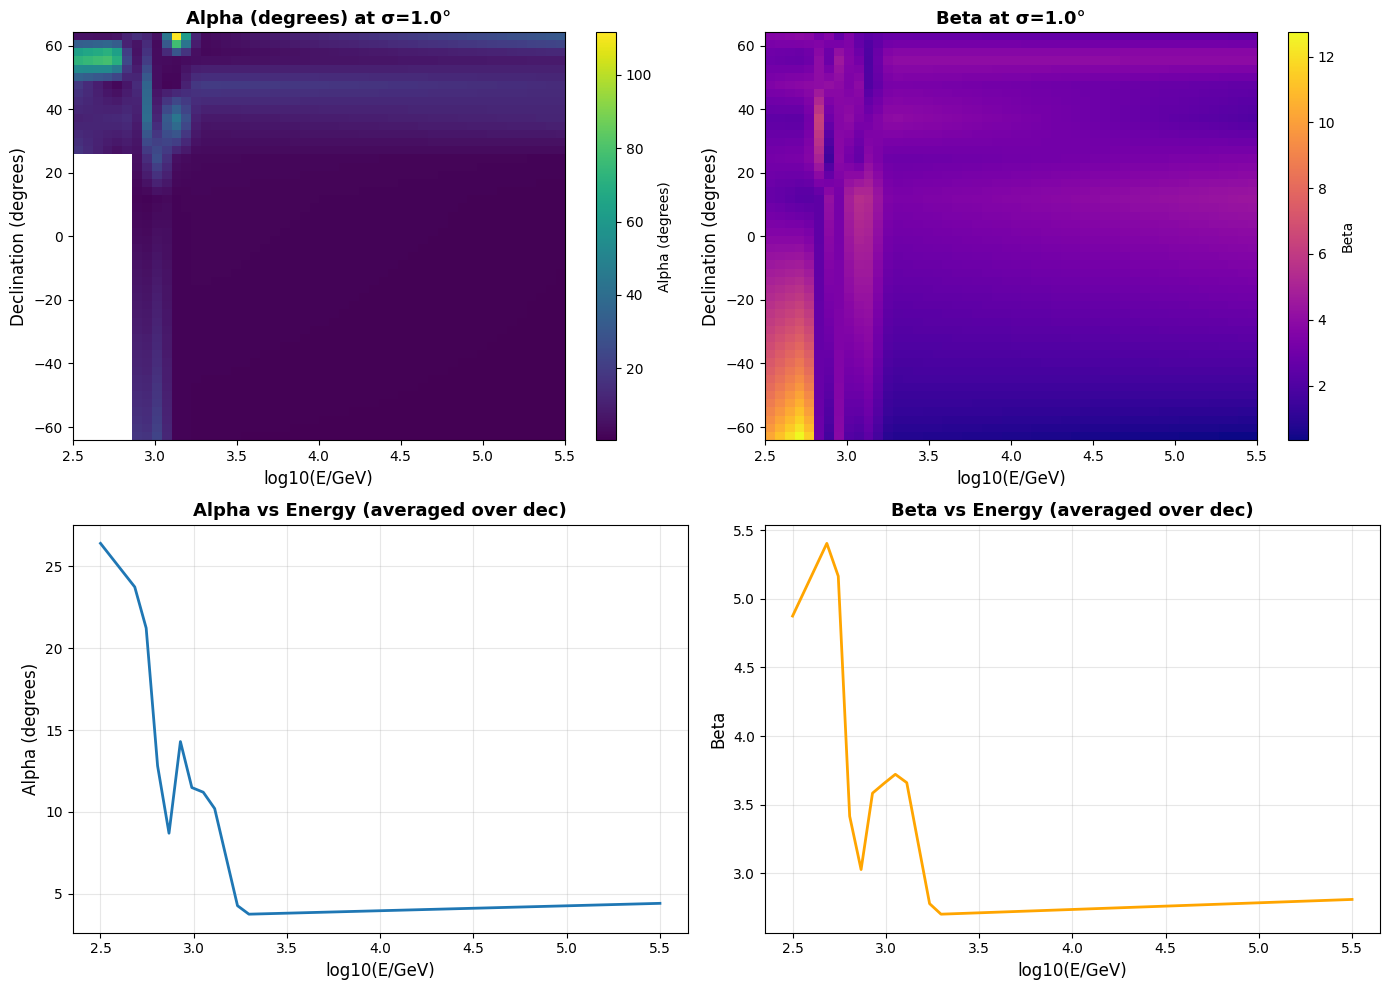


Plot generated using interpolation from internal binning:
  Energy bins for plotting: 50
  Declination bins for plotting: 50
  Fixed sigma value: 1.00°


In [16]:
# Extract results for first spectral index (gamma=2.0)
gamma_idx = 0

# Get interpolators for smooth parameter evaluation
alpha_interp, beta_interp = fitter.get_interpolator(gamma_index=gamma_idx)

# Define plotting bins - these can be arbitrary and independent of internal binning
# User can customize these for visualization
plot_energy_bins = np.linspace(2.5, 5.5, 50)   # Fine grid for smooth visualization
plot_dec_bins = np.arcsin(np.linspace(-0.9, 0.9, 50))  # Fine grid in declination

# For the sigma dimension, we'll fix at a representative value
# Could also average over sigma or create separate plots for different sigma values
# Get a reasonable sigma value from the middle of the range
if 'angErr' in fitter.bin_names:
    sigma_idx = fitter.bin_names.index('angErr')
    # Use median sigma from the fitted data
    sigma_plot = np.radians(1)  # Representative value: 1 degree
else:
    sigma_plot = np.radians(1)

# Create meshgrid for evaluation
energy_grid, dec_grid = np.meshgrid(plot_energy_bins, plot_dec_bins, indexing='ij')

# Prepare evaluation points: shape (n_points, n_dims)
# Need to match the dimension order expected by the interpolator
n_points = energy_grid.size
eval_points = np.zeros((n_points, len(fitter.bin_names)))

# Fill in the dimensions
for i, name in enumerate(fitter.bin_names):
    if name == 'logE':
        eval_points[:, i] = energy_grid.ravel()
    elif name == 'dec':
        eval_points[:, i] = dec_grid.ravel()
    elif name == 'angErr':
        eval_points[:, i] = sigma_plot  # Fixed value for all points
    else:
        raise KeyError(f"Name {name} in binning isn't implemented.")

# Evaluate interpolators
alpha_grid = alpha_interp(eval_points).reshape(energy_grid.shape)
beta_grid = beta_interp(eval_points).reshape(energy_grid.shape)

# Create a 2D visualization: alpha vs energy and declination
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot alpha as function of energy and declination
im1 = axes[0,0].imshow(np.degrees(alpha_grid.T), aspect='auto', origin='lower',
                        extent=[plot_energy_bins[0], plot_energy_bins[-1],
                               np.degrees(plot_dec_bins[0]), np.degrees(plot_dec_bins[-1])],
                        cmap='viridis')
axes[0,0].set_xlabel('log10(E/GeV)', fontsize=12)
axes[0,0].set_ylabel('Declination (degrees)', fontsize=12)
axes[0,0].set_title(f'Alpha (degrees) at σ={np.degrees(sigma_plot):.1f}°', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0,0], label='Alpha (degrees)')

# Plot beta as function of energy and declination
im2 = axes[0,1].imshow(beta_grid.T, aspect='auto', origin='lower',
                        extent=[plot_energy_bins[0], plot_energy_bins[-1],
                               np.degrees(plot_dec_bins[0]), np.degrees(plot_dec_bins[-1])],
                        cmap='plasma')
axes[0,1].set_xlabel('log10(E/GeV)', fontsize=12)
axes[0,1].set_ylabel('Declination (degrees)', fontsize=12)
axes[0,1].set_title(f'Beta at σ={np.degrees(sigma_plot):.1f}°', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[0,1], label='Beta')

# Plot alpha vs energy (averaged over declination)
alpha_vs_energy = np.nanmean(alpha_grid, axis=1)
axes[1,0].plot(plot_energy_bins, np.degrees(alpha_vs_energy), '-', linewidth=2)
axes[1,0].set_xlabel('log10(E/GeV)', fontsize=12)
axes[1,0].set_ylabel('Alpha (degrees)', fontsize=12)
axes[1,0].set_title('Alpha vs Energy (averaged over dec)', fontsize=13, fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Plot beta vs energy (averaged over declination)
beta_vs_energy = np.nanmean(beta_grid, axis=1)
axes[1,1].plot(plot_energy_bins, beta_vs_energy, '-', linewidth=2, color='orange')
axes[1,1].set_xlabel('log10(E/GeV)', fontsize=12)
axes[1,1].set_ylabel('Beta', fontsize=12)
axes[1,1].set_title('Beta vs Energy (averaged over dec)', fontsize=13, fontweight='bold')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPlot generated using interpolation from internal binning:")
print(f"  Energy bins for plotting: {len(plot_energy_bins)}")
print(f"  Declination bins for plotting: {len(plot_dec_bins)}")
print(f"  Fixed sigma value: {np.degrees(sigma_plot):.2f}°")

## 6. Examine Individual Fits

Look at the quality of fit in specific bins.

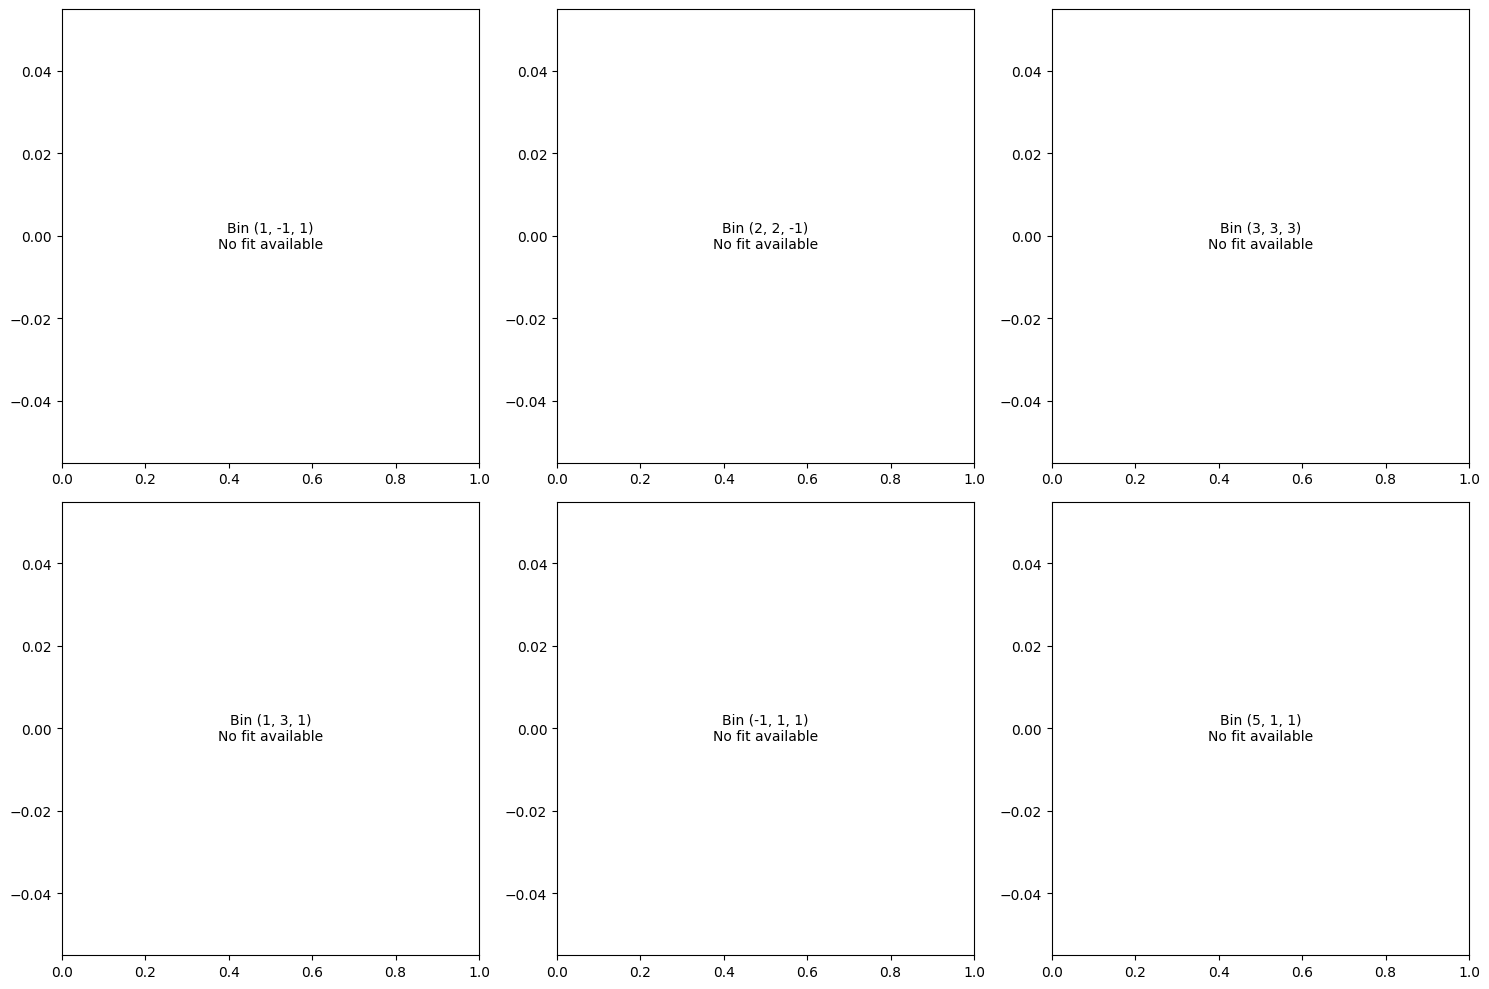

In [12]:
# Plot fits for a few example bins
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select some bins to visualize
example_bins = [
    (1, -1, 1),  # Low energy, low dec
    (2, 2, -1),  # Mid energy, mid dec
    (3, 3, 3),  # High energy, high dec
    (1, 3, 1),  # Low energy, high dec
    (-1, 1, 1),  # High energy, low dec
    (5, 1, 1),  # Mid energy, low dec
]

for i, bin_idx in enumerate(example_bins):
    if i >= len(axes):
        break
    
    try:
        fitter.plot_fit(bin_indices=bin_idx, gamma_index=0, ax=axes[i])
        axes[i].set_xscale('log')
    except Exception as e:
        axes[i].text(0.5, 0.5, f'Bin {bin_idx}\nNo fit available', 
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_xlim(0, 1)
        #axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Use Interpolators for Continuous Evaluation

Get interpolators to evaluate fitted parameters at arbitrary points.

In [15]:
# Get interpolators for gamma=2.0
try:
    alpha_interp, beta_interp = fitter.get_interpolator(gamma_index=0)
    
    # Evaluate at some test points
    test_points = np.array([
        [3.5, np.arcsin(0.0), np.radians(1.0)],   # log10E=3.5, sin(dec)=0.0, sigma=1deg
        [4.5, np.arcsin(0.5), np.radians(0.5)],   # log10E=4.5, sin(dec)=0.5, sigma=0.5deg
        [5.5, np.arcsin(-0.5), np.radians(2.0)],  # log10E=5.5, sin(dec)=-0.5, sigma=2deg
    ])
    
    alpha_values = alpha_interp(test_points)
    beta_values = beta_interp(test_points)
    
    print("Interpolated values at test points:")
    print("log10E  sin(dec)  sigma(deg)  ->  alpha(deg)  beta")
    print("-" * 60)
    for i, point in enumerate(test_points):
        print(f"{point[0]:6.2f}  {point[1]:8.2f}  {np.degrees(point[2]):10.3f}  ->  "
              f"{np.degrees(alpha_values[i]):10.4f}  {beta_values[i]:6.3f}")
    
except ImportError:
    print("scipy.interpolate.RegularGridInterpolator not available")
    print("Install scipy to use interpolation features")

Interpolated values at test points:
log10E  sin(dec)  sigma(deg)  ->  alpha(deg)  beta
------------------------------------------------------------
  3.50      0.00       1.000  ->      0.6415   1.995
  4.50      0.52       0.500  ->      0.2859   1.839
  5.50     -0.52       2.000  ->      0.8410   1.621


## 8. Compare with Direct KingPDF

Verify that the fitted parameters produce reasonable PSFs.

Fitted parameters for bin (6, 7, 2):
  alpha = 0.2761 degrees
  beta = 1.826


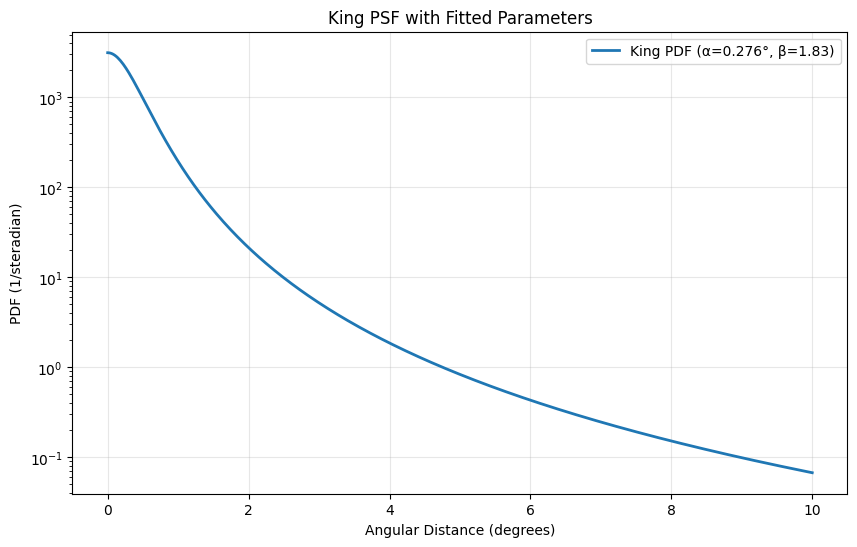


PSF containment:
  68% containment: 1.081 degrees
  90% containment: 2.162 degrees


In [17]:
# Create a King PDF object
king_pdf = KingPDF(angular_cutoff=np.pi)

# Use the fitted parameters from a specific bin
bin_idx = (6, 7, 2)  # Mid energy, mid dec, mid sigma
gamma_idx = 0

alpha = results['alpha'][gamma_idx][bin_idx]
beta = results['beta'][gamma_idx][bin_idx]

print(f"Fitted parameters for bin {bin_idx}:")
print(f"  alpha = {np.degrees(alpha):.4f} degrees")
print(f"  beta = {beta:.3f}")

# Evaluate the PDF
angles = np.linspace(0, np.radians(10), 500)
pdf_values = king_pdf.pdf(angles, alpha, beta)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.degrees(angles), pdf_values, linewidth=2, label=f'King PDF (α={np.degrees(alpha):.3f}°, β={beta:.2f})')
ax.set_xlabel('Angular Distance (degrees)')
ax.set_ylabel('PDF (1/steradian)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
ax.set_title('King PSF with Fitted Parameters')
plt.show()

# Calculate some statistics
cdf_68 = 0.0
cdf_90 = 0.0
for angle in np.linspace(0, np.pi, 1000):
    cdf = king_pdf.cdf(angle, alpha, beta)
    if cdf >= 0.68 and cdf_68 == 0:
        cdf_68 = angle
    if cdf >= 0.90 and cdf_90 == 0:
        cdf_90 = angle

print(f"\nPSF containment:")
print(f"  68% containment: {np.degrees(cdf_68):.3f} degrees")
print(f"  90% containment: {np.degrees(cdf_90):.3f} degrees")

## 9. Save Results

Save the fitted parameters for later use.

In [19]:
# Save results to file
output_dir = os.path.join(dataset_dir, 'king_fits')
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, 'king_psf_parameters.npz')

np.savez(
    output_file,
    alpha=results['alpha'],
    beta=results['beta'],
    fit_quality=results['fit_quality'],
    event_counts=results['event_counts'],
    spectral_indices=fitter.spectral_indices,
    bin_names=fitter.bin_names,
    **{f'{key}_bins': bins for key, bins in fitter.parametrization_bins.items()}
)

print(f"Saved fitted parameters to: {output_file}")

# Demonstrate loading
loaded = np.load(output_file)
print(f"\nSaved arrays:")
for key in loaded.files:
    print(f"  {key}: shape {loaded[key].shape}")
loaded.close()

Saved fitted parameters to: /Users/mjlarson/icecube/data/ana/analyses/king_fits/king_psf_parameters.npz

Saved arrays:
  alpha: shape (3, 10, 5, 10)
  beta: shape (3, 10, 5, 10)
  fit_quality: shape (3, 10, 5, 10)
  event_counts: shape (3, 10, 5, 10)
  spectral_indices: shape (3,)
  bin_names: shape (3,)
  logE_bins: shape (11,)
  dec_bins: shape (6,)
  angErr_bins: shape (11,)


## Summary

This notebook demonstrated:

1. Loading signal MC events (or generating synthetic data)
2. Setting up multi-dimensional parameterization binning
3. Fitting King PSF parameters in each bin
4. Visualizing fitted parameters across different observables
5. Examining individual fits for quality
6. Using interpolators for continuous parameter evaluation
7. Evaluating the fitted King PDF
8. Saving results for later use

The `KingPSFFitter` provides a flexible framework for parameterizing PSFs as a function of arbitrary observables, which is useful for likelihood-based analyses in neutrino astronomy.